In [1]:
%%writefile requirements.txt
# Cuántico
qiskit
qiskit-machine-learning

# Deep learning (solo notebook 03)
torch
torchvision

# Científico / datos / gráficos
numpy
pandas
matplotlib
pylatexenc

Writing requirements.txt


In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=85d3bc5ae64dddc1c20a47b3220698a2eb95d43058e9d71881a56966c401da90
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# E6 · Correlación métrica ↔ precisión de clasificación

**Notebook 03 — ¿predicen la expresibilidad y el entrelazamiento el rendimiento real?**

Para varias familias de circuito (todas a **4 qubits**, para no cambiar la CNN ni los 3 observables del pipeline de producción `Hybrid CNN-QNN.ipynb`) se:
1. entrena la HQNN (CNN + `EstimatorQNN` + `TorchConnector`) en la tarea de ruido mixto,
2. mide su accuracy de test,
3. calcula la expresibilidad ($D_{KL}$) y el entrelazamiento ($Q$) del circuito con `qexpr.py`,
4. se correlacionan ambas magnitudes.

> Requiere `torch` + `torchvision` (entorno del TFM). Usa GPU si está disponible. Ajusta `EPOCHS` y `CONFIGS` para acotar el tiempo.

In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import real_amplitudes, efficient_su2, zz_feature_map, pauli_feature_map
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

sys.path.insert(0, os.getcwd())
import qexpr as qx

SEED = 42
EPOCHS = 8            # súbelo para las cifras finales
N_SAMPLES = 2000      # muestras para las métricas de circuito
N_BINS = 75
N_QUBITS = 4

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

OUTPUT_DIR = os.path.abspath(os.path.join('..', '..', 'TFM-EXPERIMENTS', 'outputs'))
TABLES_DIR = os.path.join(OUTPUT_DIR, 'tables')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

device: cpu


## Dataset de ruido mixto (idéntico al pipeline del TFM)

In [4]:
transform = transforms.Compose([transforms.ToTensor()])
DATA_ROOT = os.path.abspath(os.path.join('..', 'data'))  # reutiliza TFM/data si existe
X_train = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
X_test = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=transform)

n_samples_train, n_samples_test = 400, 100
X_train.data = X_train.data[:n_samples_train]
X_train.targets = X_train.targets[:n_samples_train]
X_test.data = X_test.data[:n_samples_test]
X_test.targets = X_test.targets[:n_samples_test]

g = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(X_train, [300, 100], generator=g)

# Parámetros de ruido de config/common.yaml
def gaussian_noise(img, sigma=0.25):
    return torch.clamp(img + torch.randn_like(img) * sigma, 0, 1)

def salt_pepper(img, prob=0.15):
    noisy = img.clone(); mask = torch.rand_like(img)
    noisy[mask < prob / 2] = 0; noisy[mask > 1 - prob / 2] = 1
    return noisy

def speckle(img, sigma=0.35):
    return torch.clamp(img + img * torch.randn_like(img) * sigma, 0, 1)

def apply_mixed_noise(img):
    r = np.random.randint(3)
    if r == 0:
        img = speckle(gaussian_noise(img)); label = 0
    elif r == 1:
        img = salt_pepper(gaussian_noise(img)); label = 1
    else:
        img = speckle(salt_pepper(img)); label = 2
    return img, label

class NoisyMNISTDataset(Dataset):
    def __init__(self, mnist_dataset):
        self.noisy_images, self.labels = [], []
        for img, _ in mnist_dataset:
            noisy_img, label = apply_mixed_noise(img)
            self.noisy_images.append(noisy_img); self.labels.append(label)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.noisy_images[idx], self.labels[idx]

train_loader = DataLoader(NoisyMNISTDataset(train_subset), batch_size=32, shuffle=True)
val_loader = DataLoader(NoisyMNISTDataset(val_subset), batch_size=32, shuffle=False)
test_loader = DataLoader(NoisyMNISTDataset(X_test), batch_size=32, shuffle=False)
print('batches train/val/test:', len(train_loader), len(val_loader), len(test_loader))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.70MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.44MB/s]


batches train/val/test: 10 4 4


## QNN + red híbrida (parametrizadas por la familia de circuito)

In [5]:
estimator = StatevectorEstimator()
observables = [
    SparsePauliOp.from_list([('ZIII', 1.0), ('IZII', 1.0)]),
    SparsePauliOp.from_list([('ZZII', 1.0)]),
    SparsePauliOp.from_list([('IIZZ', 1.0)]),
]

def build_fm_ansatz(fm_name, an_name, an_entanglement, reps, n_qubits=N_QUBITS):
    if fm_name == 'zz':
        fm = zz_feature_map(n_qubits, entanglement='full', reps=1)
    else:
        fm = pauli_feature_map(n_qubits, paulis=['X', 'Y', 'ZZ'], entanglement='full', reps=1)
    if an_name == 'real_amplitudes':
        an = real_amplitudes(n_qubits, entanglement=an_entanglement, reps=reps)
    else:
        an = efficient_su2(n_qubits, entanglement=an_entanglement, reps=reps)
    qc = QuantumCircuit(n_qubits)
    qc.compose(fm, inplace=True)
    qc.compose(an, inplace=True)
    return fm, an, qc

def create_qnn(fm, an, qc):
    return EstimatorQNN(circuit=qc, input_params=fm.parameters, weight_params=an.parameters,
                        input_gradients=True, estimator=estimator, observables=observables)

class Net(nn.Module):
    def __init__(self, qnn):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, N_QUBITS)
        self.qnn = TorchConnector(qnn)
        self.fc_final = nn.Identity()
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = torch.tanh(self.fc2(x)) * np.pi
        return self.fc_final(self.qnn(x))

In [6]:
def train_eval(fm_name, an_name, an_entanglement, reps):
    torch.manual_seed(SEED)
    fm, an, qc = build_fm_ansatz(fm_name, an_name, an_entanglement, reps)
    model = Net(create_qnn(fm, an, qc)).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    for _ in range(EPOCHS):
        model.train()
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            opt.zero_grad(); loss = crit(model(data), target); loss.backward(); opt.step()
    # test accuracy
    model.eval(); correct = total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            _, pred = torch.max(model(data), 1)
            correct += (pred == target).sum().item(); total += target.size(0)
    acc = correct / total
    # métricas del circuito (mismo qc)
    m = qx.descriptors(qc, N_QUBITS, n_samples=N_SAMPLES, n_bins=N_BINS, seed=SEED)
    return acc, m

## Configuraciones candidatas (todas a 4 qubits)

In [ ]:
# (etiqueta, feature_map, ansatz, entanglement_ansatz, reps)
CONFIGS = [
    ('zz+RA (rev_lin, r1) [prod]', 'zz',    'real_amplitudes', 'reverse_linear', 1),
    ('zz+RA (full, r1)',           'zz',    'real_amplitudes', 'full',           1),
    ('zz+RA (rev_lin, r2)',        'zz',    'real_amplitudes', 'reverse_linear', 2),
    ('zz+ESU2 (rev_lin, r1)',      'zz',    'efficient_su2',   'reverse_linear', 1),
    ('pauli+RA (rev_lin, r1)',     'pauli', 'real_amplitudes', 'reverse_linear', 1),
    ('pauli+ESU2 (rev_lin, r1)',   'pauli', 'efficient_su2',   'reverse_linear', 1),
]

rows = []
for label, fm, an, ent, reps in CONFIGS:
    acc, m = train_eval(fm, (an, ent, reps)
    rows.append({'circuit': label, 'test_acc': acc,
                 'expressibility_kl': m['expressibility_kl'],
                 'entangling_Q': m['entangling_Q'],
                 'n_params': m['n_params'], 'depth': m['depth']})
    print(f"{label:30s}  acc={acc:.3f}  KL={m['expressibility_kl']:.3f}  Q={m['entangling_Q']:.3f}")

dfc = pd.DataFrame(rows)
dfc.to_csv(os.path.join(TABLES_DIR, 'E6_metric_vs_accuracy.csv'), index=False)
dfc

zz+RA (rev_lin, r1) [prod]      acc=0.930  KL=0.009  Q=0.835


zz+RA (full, r1)                acc=0.330  KL=0.009  Q=0.835


zz+RA (rev_lin, r2)             acc=0.970  KL=0.007  Q=0.832


zz+ESU2 (rev_lin, r1)           acc=0.680  KL=0.008  Q=0.830


pauli+RA (rev_lin, r1)          acc=0.340  KL=0.020  Q=0.630
pauli+ESU2 (rev_lin, r1)        acc=1.000  KL=0.007  Q=0.699


,circuit,test_acc,expressibility_kl,entangling_Q,n_params,depth
0,"zz+RA (rev_lin, r1) [prod]",0.93,0.008928,0.834993,12,22
1,"zz+RA (full, r1)",0.33,0.008928,0.834993,12,23
2,"zz+RA (rev_lin, r2)",0.97,0.006976,0.832146,16,25
3,"zz+ESU2 (rev_lin, r1)",0.68,0.007948,0.830142,20,24
4,"pauli+RA (rev_lin, r1)",0.34,0.020220,0.630375,12,31
5,"pauli+ESU2 (rev_lin, r1)",1.00,0.007032,0.698853,20,33


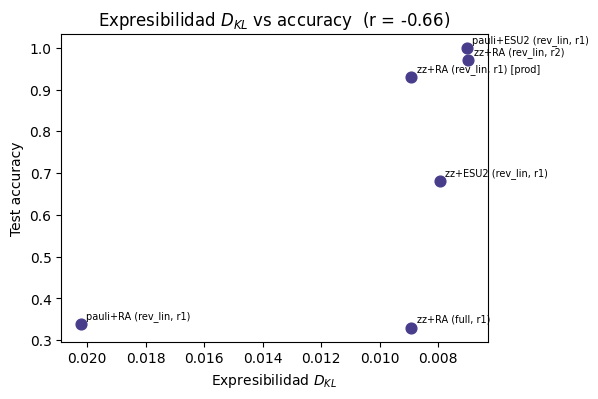

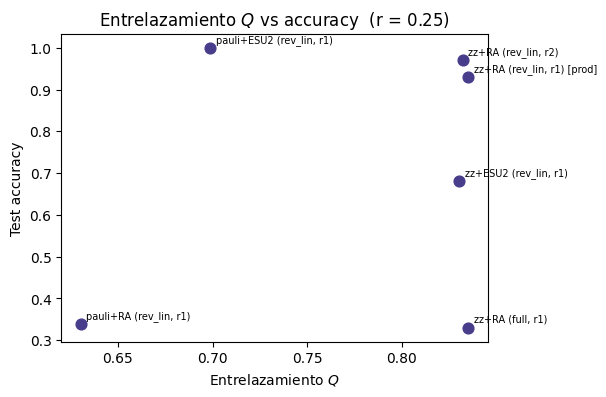

Correlacion accuracy~KL: -0.659 | accuracy~Q: 0.252


In [ ]:
def scatter(xcol, xlabel, fname, invert=False):
    x = dfc[xcol].values; y = dfc['test_acc'].values
    r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else float('nan')
    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.scatter(x, y, s=60, color='darkslateblue')
    for _, row in dfc.iterrows():
        ax.annotate(row['circuit'], (row[xcol], row['test_acc']), fontsize=7,
                    xytext=(4, 4), textcoords='offset points')
    ax.set_xlabel(xlabel); ax.set_ylabel('Test accuracy')
    ax.set_title(f'{xlabel} vs accuracy  (r = {r:.2f})')
    if invert:
        ax.invert_xaxis()
    qx.savefig(fig, os.path.join(FIGURES_DIR, fname))
    plt.show()
    return r

# Expresibilidad: KL menor = mas expresivo -> eje invertido para leer 'mas expresivo' a la derecha
r_expr = scatter('expressibility_kl', 'Expresibilidad $D_{KL}$', 'E6_expr_vs_accuracy.png', invert=True)
r_ent = scatter('entangling_Q', 'Entrelazamiento $Q$', 'E6_ent_vs_accuracy.png')
print(f'Correlacion accuracy~KL: {r_expr:.3f} | accuracy~Q: {r_ent:.3f}')

## Interpretación (para la memoria)

- Un **KL bajo** (más expresivo) y/o **Q alto** (más entrelazamiento) que se asocien a mayor accuracy respaldarían la elección del circuito; una correlación débil sugeriría que en esta tarea (dataset pequeño, features ya separables por la CNN) el circuito no es el cuello de botella.
- La tarea de ruido mixto es fácilmente separable (la CNN de producción llega a ~100%), por lo que el techo de accuracy puede enmascarar diferencias: conviene reportar también con la CNN congelada o menos épocas si se busca discriminar circuitos.

Artefactos: `E6_metric_vs_accuracy.csv`, `E6_expr_vs_accuracy.png`, `E6_ent_vs_accuracy.png`.